In [1]:
# Install packages
!pip install -q roboflow ultralytics pyyaml

In [2]:
# Import libraries
import os
import shutil
import yaml
from glob import glob

from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Download both Roboflow datasets
rf = Roboflow(api_key="lTH39WRpHZJHPlMVsCyG")

# Dataset 1
project1 = rf.workspace("vruddhis-workspace").project("water-waste-eouzy-ub9vw")
version1 = project1.version(1)
dataset1 = version1.download("yolov8")

# Dataset 2
project2 = rf.workspace("vruddhis-workspace").project("plastic-on-water-kctvo-cr3yy")
version2 = project2.version(1)
dataset2 = version2.download("yolov8")

print("Dataset 1 location:", dataset1.location)
print("Dataset 2 location:", dataset2.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Water-Waste-1 in yolov8:: 100%|██████████| 16763/16763 [00:02<00:00, 8355.16it/s] 


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plastic-on-water-1 in yolov8:: 100%|██████████| 7199/7199 [00:00<00:00, 7561.58it/s]

Dataset 1 location: /kaggle/working/Water-Waste-1
Dataset 2 location: /kaggle/working/Plastic-on-water-1


In [4]:
# Inspect class names
def read_yaml_classes(yaml_path):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    return data["names"]

data1_yaml = os.path.join(dataset1.location, "data.yaml")
data2_yaml = os.path.join(dataset2.location, "data.yaml")

classes1 = read_yaml_classes(data1_yaml)
classes2 = read_yaml_classes(data2_yaml)

print("Dataset 1 classes:")
for i, name in enumerate(classes1):
    print(i, "->", name)

print("\nDataset 2 classes:")
for i, name in enumerate(classes2):
    print(i, "->", name)

Dataset 1 classes:
0 -> bottle
1 -> bottle_cap
2 -> can
3 -> cigarette
4 -> cup
5 -> lid
6 -> plastic_cover_bag
7 -> snack_wrapper

Dataset 2 classes:
0 -> non-plastic
1 -> plastic


In [5]:
# Create single-class mapping
final_classes = ["waste"]

dataset1_class_map = {i: 0 for i in range(len(classes1))}
dataset2_class_map = {i: 0 for i in range(len(classes2))}

print("Final classes:", final_classes)

print("\nDataset 1 mapping:")
for old_idx in dataset1_class_map:
    print(f"{old_idx} ({classes1[old_idx]}) -> 0 (waste)")

print("\nDataset 2 mapping:")
for old_idx in dataset2_class_map:
    print(f"{old_idx} ({classes2[old_idx]}) -> 0 (waste)")

Final classes: ['waste']

Dataset 1 mapping:
0 (bottle) -> 0 (waste)
1 (bottle_cap) -> 0 (waste)
2 (can) -> 0 (waste)
3 (cigarette) -> 0 (waste)
4 (cup) -> 0 (waste)
5 (lid) -> 0 (waste)
6 (plastic_cover_bag) -> 0 (waste)
7 (snack_wrapper) -> 0 (waste)

Dataset 2 mapping:
0 (non-plastic) -> 0 (waste)
1 (plastic) -> 0 (waste)


In [6]:
# Merge both datasets into one
MERGED_DIR = "/kaggle/working/AQUASCAN_MERGED"

# Remove old merged dataset if it exists
if os.path.exists(MERGED_DIR):
    shutil.rmtree(MERGED_DIR)

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"{MERGED_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{MERGED_DIR}/{split}/labels", exist_ok=True)

def remap_and_copy_dataset(dataset_path, class_map, prefix):
    for split in ["train", "valid", "test"]:
        image_dir = os.path.join(dataset_path, split, "images")
        label_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.exists(image_dir):
            print(f"Skipping missing image folder: {image_dir}")
            continue

        image_files = glob(os.path.join(image_dir, "*"))

        for img_path in image_files:
            filename = os.path.basename(img_path)
            base_name, ext = os.path.splitext(filename)
            label_path = os.path.join(label_dir, base_name + ".txt")

            new_img_name = f"{prefix}_{filename}"
            new_label_name = f"{prefix}_{base_name}.txt"

            # Copy image
            shutil.copy(img_path, os.path.join(MERGED_DIR, split, "images", new_img_name))

            # Read label and remap class IDs
            new_lines = []
            if os.path.exists(label_path):
                with open(label_path, "r") as f:
                    lines = f.readlines()

                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue

                    old_class_id = int(parts[0])
                    if old_class_id not in class_map:
                        continue

                    new_class_id = class_map[old_class_id]
                    new_line = " ".join([str(new_class_id)] + parts[1:])
                    new_lines.append(new_line)

            with open(os.path.join(MERGED_DIR, split, "labels", new_label_name), "w") as f:
                f.write("\n".join(new_lines))

# Merge both datasets
remap_and_copy_dataset(dataset1.location, dataset1_class_map, "ds1")
remap_and_copy_dataset(dataset2.location, dataset2_class_map, "ds2")

print("Merged dataset created at:", MERGED_DIR)

Merged dataset created at: /kaggle/working/AQUASCAN_MERGED


In [7]:
# Create final data.yaml
merged_data_yaml = {
    "path": MERGED_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": final_classes
}

with open(f"{MERGED_DIR}/data.yaml", "w") as f:
    yaml.dump(merged_data_yaml, f, sort_keys=False)

print("Created merged data.yaml:")
print(merged_data_yaml)

Created merged data.yaml:
{'path': '/kaggle/working/AQUASCAN_MERGED', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'names': ['waste']}


In [8]:
# Check merged dataset counts
for split in ["train", "valid", "test"]:
    img_count = len(os.listdir(f"{MERGED_DIR}/{split}/images"))
    lbl_count = len(os.listdir(f"{MERGED_DIR}/{split}/labels"))
    print(f"{split}: {img_count} images | {lbl_count} labels")

train: 9218 images | 9218 labels
valid: 1533 images | 1533 labels
test: 1225 images | 1225 labels


In [9]:
# Train the model
model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{MERGED_DIR}/data.yaml",
    epochs=20,
    imgsz=512,
    batch=8,
    patience=5,
    device=0,
    project="/kaggle/working/aquascan_training",
    name="aquascan_single_class",
    pretrained=True,
    cache=False
)

Ultralytics 8.4.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/AQUASCAN_MERGED/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aquascan_single_class, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [10]:
# Validate the best model
best_model_path = "/kaggle/working/aquascan_training/aquascan_single_class/weights/best.pt"
last_model_path = "/kaggle/working/aquascan_training/aquascan_single_class/weights/last.pt"

print("Best model path:", best_model_path)
print("Last model path:", last_model_path)

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    metrics = best_model.val(data=f"{MERGED_DIR}/data.yaml")
    print("\nValidation complete.")
    print(metrics)
else:
    print("best.pt not found.")

Best model path: /kaggle/working/aquascan_training/aquascan_single_class/weights/best.pt
Last model path: /kaggle/working/aquascan_training/aquascan_single_class/weights/last.pt
Ultralytics 8.4.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1202.9±621.2 MB/s, size: 43.4 KB)
val: Scanning /kaggle/working/AQUASCAN_MERGED/valid/labels.cache... 1533 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1533/1533 535.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 235, len(boxes) = 2346. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 9.0it/s 10.6s0.2s
                   

In [11]:
# Save final model to easy path
FINAL_BEST_PATH = "/kaggle/working/AquaScan_best.pt"

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, FINAL_BEST_PATH)
    print("Copied final model to:", FINAL_BEST_PATH)
else:
    print("Could not copy because best.pt does not exist.")

Copied final model to: /kaggle/working/AquaScan_best.pt


In [53]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [93]:
import os

uploaded_file = uploader.value[0]

filename = uploaded_file["name"]
content = uploaded_file["content"]

with open(filename, "wb") as f:
    f.write(content)

image_path = os.path.abspath(filename)
print("Saved image at:", image_path)

Saved image at: /kaggle/working/aquascan waste.jpg


In [94]:
results = model.predict(
    source=image_path,
    conf=0.12,
    iou=0.45,
    max_det=100,
    save=True,
    imgsz=512
)

result = results[0]

print("Prediction completed.")
print("Saved results in:", result.save_dir)


image 1/1 /kaggle/working/aquascan waste.jpg: 352x512 8 wastes, 7.8ms
Speed: 2.1ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 512)
Results saved to /kaggle/working/runs/detect/predict-14
Prediction completed.
Saved results in: /kaggle/working/runs/detect/predict-14


In [97]:
# ---------- CELL 6: REPORT GENERATOR ----------
def generate_aquascan_report(result):
    h, w = result.orig_shape
    image_area = h * w
    boxes = result.boxes

    # -------- IMAGE TOO SMALL / UNCLEAR --------
    if w < 400 or h < 400:
        return {
            "pollutionType": "Image Unclear",
            "severity": "UNKNOWN",
            "urgency": "N/A",
            "density": "Unknown",
            "coverage": "N/A",
            "confidence": "Low",
            "description": "The uploaded image is too small or unclear for reliable aquatic waste analysis.",
            "recommendation": "Please capture or upload a clearer image with better visibility of the water surface.",
            "needsBetterImage": True
        }

    # -------- NO DETECTIONS AT ALL --------
    if boxes is None or len(boxes) == 0:
        return {
            "pollutionType": "No Significant Aquatic Waste Detected",
            "severity": "LOW",
            "urgency": "1/10",
            "density": "Minimal",
            "coverage": "0%",
            "confidence": "Low",
            "description": "The uploaded image appears clean and does not show any significant visible aquatic waste.",
            "recommendation": "No immediate cleanup action is required. Continue regular monitoring.",
            "needsBetterImage": False
        }

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()

    candidate_boxes = []
    candidate_confs = []
    candidate_area = 0

    strong_boxes = []
    strong_confs = []
    strong_area = 0

    for box, conf in zip(xyxy, confs):
        x1, y1, x2, y2 = box
        box_area = max(0, x2 - x1) * max(0, y2 - y1)
        area_ratio = box_area / image_area

        # Reject giant nonsense boxes
        if area_ratio > 0.35:
            continue

        # Scene understanding detections
        if conf >= 0.12:
            candidate_boxes.append(box)
            candidate_confs.append(float(conf))
            candidate_area += box_area

        # Strong detections
        if conf >= 0.30:
            strong_boxes.append(box)
            strong_confs.append(float(conf))
            strong_area += box_area

    avg_conf = float(np.mean(candidate_confs)) if candidate_confs else 0.0
    candidate_count = len(candidate_boxes)

    # -------- IMAGE UNCLEAR CASE --------
    if candidate_count == 0 and avg_conf < 0.15:
        return {
            "pollutionType": "Image Unclear",
            "severity": "UNKNOWN",
            "urgency": "N/A",
            "density": "Unknown",
            "coverage": "N/A",
            "confidence": "Low",
            "description": "The image does not provide strong enough visual evidence for reliable waste analysis.",
            "recommendation": "Please capture or upload a clearer image with proper lighting and a visible water surface.",
            "needsBetterImage": True
        }

    # -------- CLEAN IMAGE CASE --------
    if candidate_count <= 2 and avg_conf < 0.20:
        return {
            "pollutionType": "No Significant Aquatic Waste Detected",
            "severity": "LOW",
            "urgency": "1/10",
            "density": "Minimal",
            "coverage": "0%",
            "confidence": "Low",
            "description": "The uploaded image appears clean or does not contain strong evidence of aquatic waste.",
            "recommendation": "No immediate cleanup action is required. Continue regular monitoring.",
            "needsBetterImage": False
        }

    # -------- COVERAGE --------
    strong_coverage = min((strong_area / image_area) * 100, 100)
    candidate_coverage = min((candidate_area / image_area) * 100, 100)

    # -------- SPREAD ACROSS IMAGE --------
    x_mins = [b[0] for b in candidate_boxes]
    y_mins = [b[1] for b in candidate_boxes]
    x_maxs = [b[2] for b in candidate_boxes]
    y_maxs = [b[3] for b in candidate_boxes]

    spread_width = (max(x_maxs) - min(x_mins)) / w if candidate_boxes else 0
    spread_height = (max(y_maxs) - min(y_mins)) / h if candidate_boxes else 0
    spread_score = (spread_width + spread_height) / 2

    # -------- EFFECTIVE COVERAGE --------
    effective_coverage = max(strong_coverage, candidate_coverage * 0.65)

    # Scene boost for dense widespread clutter
    if candidate_count >= 10 and spread_score >= 0.55:
        effective_coverage += 18
    elif candidate_count >= 7 and spread_score >= 0.45:
        effective_coverage += 10
    elif candidate_count >= 4 and spread_score >= 0.35:
        effective_coverage += 5

    effective_coverage = min(effective_coverage, 100)

    # -------- DENSITY --------
    if effective_coverage >= 35:
        density = "Very High"
    elif effective_coverage >= 18:
        density = "High"
    elif effective_coverage >= 7:
        density = "Moderate"
    else:
        density = "Low"

    # -------- SEVERITY + URGENCY --------
    if effective_coverage >= 25 or (candidate_count >= 8 and spread_score >= 0.5):
        severity = "HIGH"
        urgency = "9/10"
    elif effective_coverage >= 10 or (candidate_count >= 4 and spread_score >= 0.35):
        severity = "MEDIUM"
        urgency = "6/10"
    else:
        severity = "LOW"
        urgency = "3/10"

    # -------- POLLUTION TYPE --------
    if severity == "HIGH":
        pollution_type = "Heavy Floating Waste Pollution"
    elif severity == "MEDIUM":
        pollution_type = "Moderate Floating Waste Pollution"
    else:
        pollution_type = "Localized Floating Waste"

    # -------- CONFIDENCE LABEL --------
    if avg_conf >= 0.60:
        confidence = "High"
    elif avg_conf >= 0.30:
        confidence = "Medium"
    else:
        confidence = "Low"

    ui_coverage = round(float(effective_coverage), 1)

    # -------- DESCRIPTION + RECOMMENDATION --------
    if severity == "HIGH":
        description = (
            f"A large amount of floating waste is visible across the scene, with an estimated coverage "
            f"of {ui_coverage}% of the visible area. The pollution appears widespread and densely concentrated, "
            f"indicating severe aquatic pollution."
        )
        recommendation = (
            "Immediate cleanup action is recommended. Authorities or cleanup teams should prioritize "
            "this location and investigate the pollution source."
        )
    elif severity == "MEDIUM":
        description = (
            f"A noticeable amount of floating waste is present, with an estimated coverage of "
            f"{ui_coverage}% of the visible area. The pollution is moderate and should be addressed soon."
        )
        recommendation = (
            "Schedule cleanup soon and continue monitoring the water body for any increase in pollution."
        )
    else:
        description = (
            f"A small amount of visible floating waste is present, with an estimated coverage of "
            f"{ui_coverage}% of the visible area."
        )
        recommendation = (
            "Minor cleanup is recommended. Continue routine monitoring of the area."
        )

    return {
        "pollutionType": pollution_type,
        "severity": severity,
        "urgency": urgency,
        "density": density,
        "coverage": f"{ui_coverage}%",
        "confidence": confidence,
        "description": description,
        "recommendation": recommendation,
        "needsBetterImage": False
    }


In [98]:
# Generate final report

report = generate_aquascan_report(result)

print("AQUASCAN REPORT")
for key, value in report.items():
    print(f"{key}: {value}")


AQUASCAN REPORT
pollutionType: Heavy Floating Waste Pollution
severity: HIGH
urgency: 9/10
density: High
coverage: 26.1%
confidence: Medium
description: A large amount of floating waste is visible across the scene, with an estimated coverage of 26.1% of the visible area. The pollution appears widespread and densely concentrated, indicating severe aquatic pollution.
recommendation: Immediate cleanup action is recommended. Authorities or cleanup teams should prioritize this location and investigate the pollution source.
needsBetterImage: False


Prediction saved in: /kaggle/working/runs/detect/predict-14


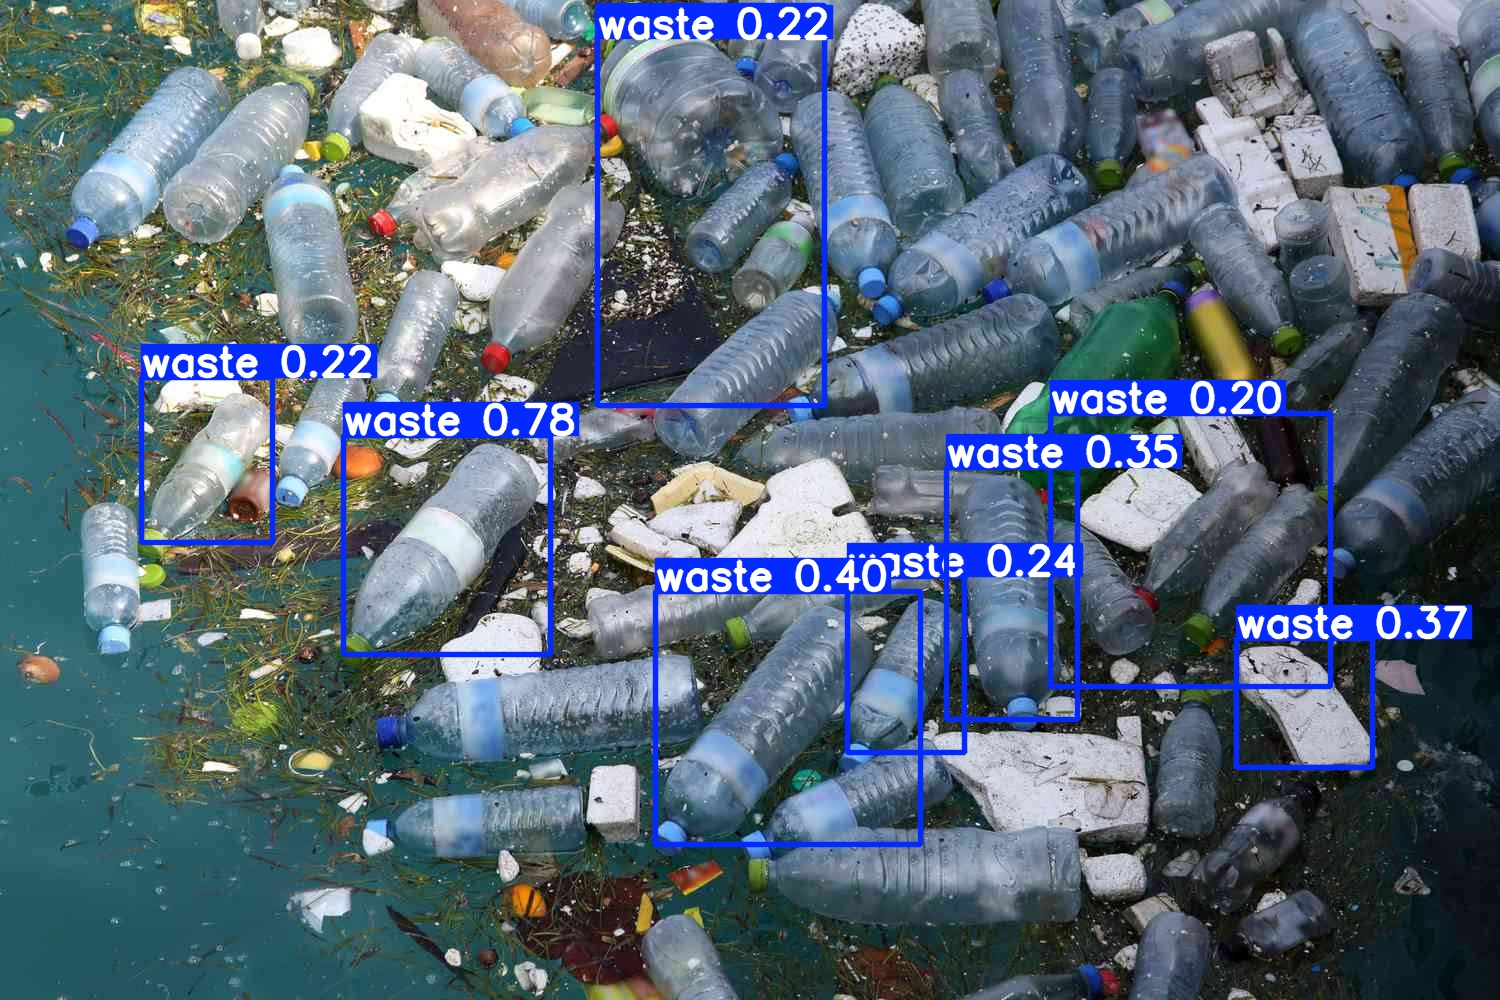

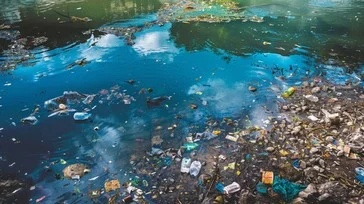

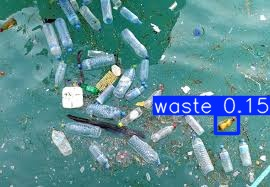

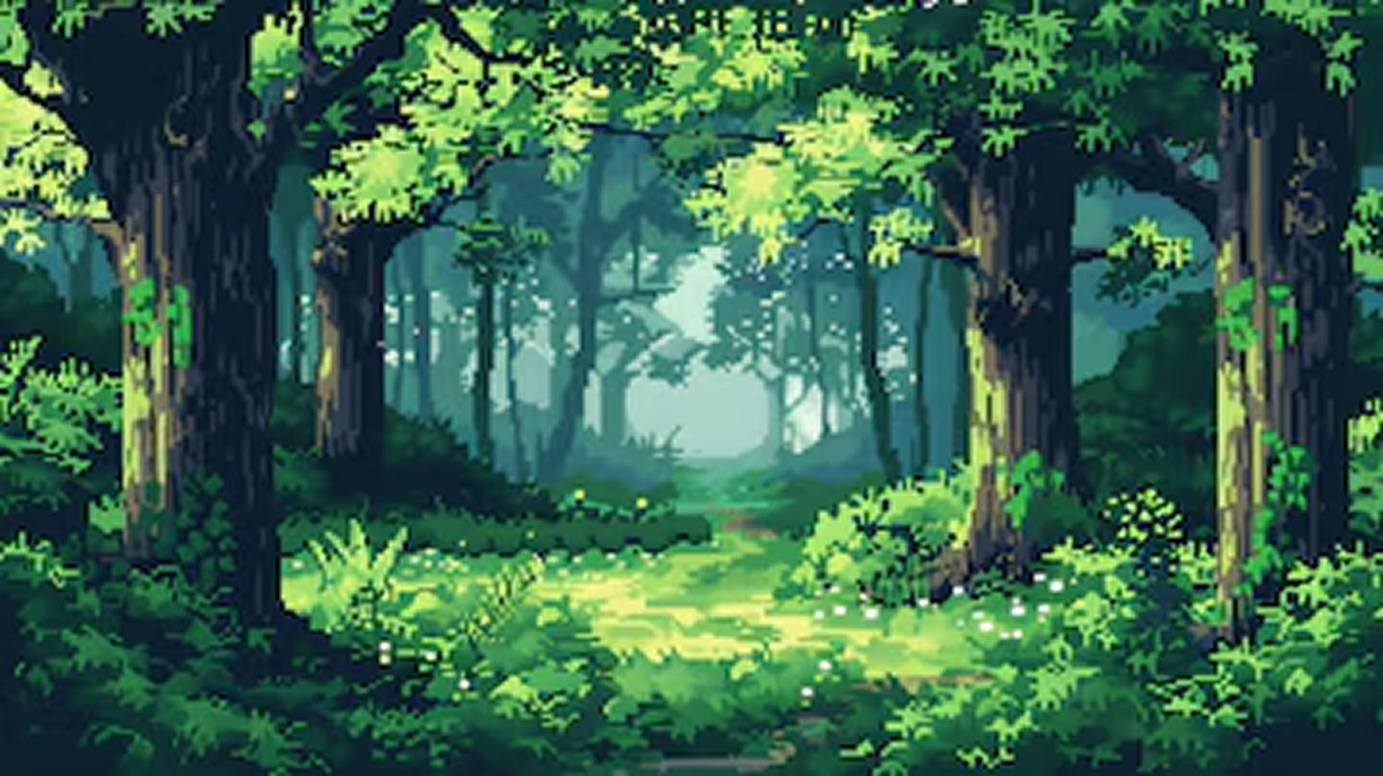

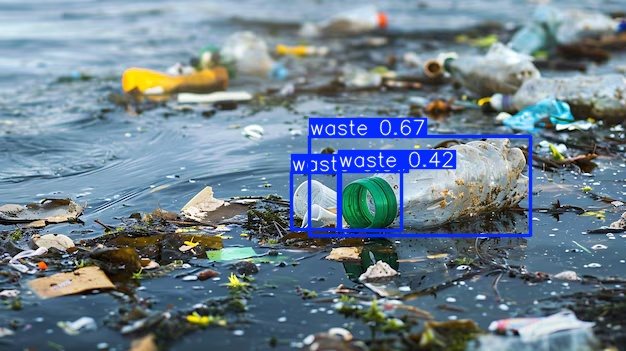

In [99]:
# Show prediction image
import os
from IPython.display import Image, display

pred_dir = results[0].save_dir
print("Prediction saved in:", pred_dir)

for file in os.listdir(pred_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        display(Image(filename=os.path.join(pred_dir, file)))

In [100]:
import json
print(json.dumps(report, indent=4))

{
    "pollutionType": "Heavy Floating Waste Pollution",
    "severity": "HIGH",
    "urgency": "9/10",
    "density": "High",
    "coverage": "26.1%",
    "confidence": "Medium",
    "description": "A large amount of floating waste is visible across the scene, with an estimated coverage of 26.1% of the visible area. The pollution appears widespread and densely concentrated, indicating severe aquatic pollution.",
    "recommendation": "Immediate cleanup action is recommended. Authorities or cleanup teams should prioritize this location and investigate the pollution source.",
    "needsBetterImage": false
}


In [ ]:
# If this model is decent, do better training
model = YOLO("yolov8s.pt")

results = model.train(
    data=f"{MERGED_DIR}/data.yaml",
    epochs=35,
    imgsz=640,
    batch=8,
    patience=8,
    device=0,
    project="/kaggle/working/aquascan_training",
    name="aquascan_single_class_better",
    pretrained=True,
    cache=False
)